In [1]:
from real_time_weather_ingestion import main_scrapper
from radar_image_processor import image_to_possible_storm
from storm_object_detector import storm_object_checker,storm_pixel_coordinates
from datetime import datetime 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image
from matplotlib import colors
from datetime import datetime, timedelta

In [2]:
all_station_data = pd.read_csv('overall_station.csv')
all_station_data.head

<bound method NDFrame.head of                    Station Name  Latitude  Longitude Station ID
0           Ang Mo Kio Avenue 5   1.37640  103.84920       S109
1                Nanyang Avenue   1.34583  103.68166        S44
2                    Pulau Ubin   1.41680  103.96730       S106
3                   Banyan Road   1.25600  103.67900       S117
4                Kim Chuan Road   1.33990  103.88780        S43
5            East Coast Parkway   1.31350  103.96250       S107
6       Upper Changi Road North   1.36780  103.98260        S24
7           Tuas South Avenue 3   1.29377  103.61843       S115
8              Semakau Landfill   1.18900  103.76800       S102
9                   Scotts Road   1.31055  103.83650       S111
10                      Sentosa   1.25000  103.82790        S60
11            Yio Chu Kang Road   1.37999  103.87643       S219
12         Ang Mo Kio Avenue 10   1.36019  103.85335       S216
13             Bishan Street 13   1.35041  103.85526       S217
14        

In [3]:
# shayne help me make sure ur weather station dataframe is named as all_station_data , then juz run this whole cell , at the end just upload all_station_data to the db will do 

########################################################################################
# do not change
lat_min, lat_max = 1.15, 1.47
lon_min, lon_max = 103.56, 104.14   
########################################################################################

########################################################################################
# do not change
scale_x = 217 / 853
scale_y = 120 / 479
########################################################################################


def latlon_to_xy(lat, lon, lat_min, lat_max, lon_min, lon_max, width, height):
    """
    Convert latitude and longitude to pixel coordinates on the radar image grid.

    Args:
        lat, lon : float
        lat_min, lat_max, lon_min, lon_max : float
            Bounding box of the radar coverage.
        width, height : int
            Dimensions of the radar image (e.g. 217x120).

    Returns:
        (x, y) pixel coordinates (integers)
    """

    # normalize longitude to horizontal position
    x = (lon - lon_min) / (lon_max - lon_min) * (width - 1)
    # normalize latitude to vertical position (note inversion: north is top)
    y = (lat_max - lat) / (lat_max - lat_min) * (height - 1)

    return int(round(x)), int(round(y))

def basemap_to_radar(X, Y):
    x = X * scale_x
    y = Y * scale_y
    return int(round(x)), int(round(y))

all_station_data['coord_basemap'] = all_station_data.apply(lambda row : latlon_to_xy(row['Latitude'],row['Longitude'],lat_min, lat_max, lon_min, lon_max,853,479),axis = 1)

all_station_data.rename(columns={'Station Name':'station_name','Latitude':'latitude','Longitude':'longitude','Station ID':'station_id'},inplace = True)


all_station_data["coord"] = all_station_data["coord_basemap"].apply(lambda xy: basemap_to_radar(xy[0], xy[1]))

In [4]:

# Define start and end times
start_time = datetime(2025, 10, 9, 10, 0)
end_time   = datetime(2025, 10, 9, 10, 30)

# Generate list at 5-min intervals
timestamps = []
current = start_time
while current <= end_time:
    timestamps.append(current.isoformat())
    current += timedelta(minutes=5)

print(timestamps[0])

2025-10-09T10:00:00


In [5]:
# fake pipeline 

possible_storm_combined = pd.DataFrame() 
possible_storm_grid_combined = pd.DataFrame()



for ts in timestamps: 
    
    stations = all_station_data.copy()

    weather_data = main_scrapper(ts)

    weather_and_station = weather_data.merge(stations, on = 'station_id', how = 'left')

    image_path = 'dummy_generator/'+ts+'.png'

    print(image_path)

    with open(image_path,'rb') as f:
        data = f.read()
    
    possible_storm_grid , possible_storm_df = image_to_possible_storm(data,40,80)


    final_storm_df = possible_storm_df.copy()

    final_storm_df['output'] = final_storm_df['grid_id'].apply(lambda x: storm_object_checker(x,possible_storm_grid,weather_and_station,5,2,24,90,40))

    final_storm_df = final_storm_df[final_storm_df['output']]
    print(final_storm_df["grid_id"].unique())

    final_storm_df['timestamp'] = ts # from above 
    new_order = ['timestamp','grid_id','centroid_x','centroid_y','anchor_x','anchor_y','peak_dbz','area_px','output']
    final_storm_df = final_storm_df[new_order]
    final_storm_df.drop(columns = ['output'],inplace = True)



    to_keep = final_storm_df["grid_id"].unique()
    final_storm_grid = np.where(np.isin(possible_storm_grid, to_keep), possible_storm_grid, 0)

    grid_row = pd.DataFrame({"timestamp": [ts], "grid": [final_storm_grid]})
    possible_storm_combined=pd.concat([possible_storm_combined,final_storm_df],ignore_index=True)
    possible_storm_grid_combined = pd.concat(
        [possible_storm_grid_combined, grid_row],
        ignore_index=True
    )


dummy_generator/2025-10-09T10:00:00.png
[3 4 5]
dummy_generator/2025-10-09T10:05:00.png
[1 2 3]
dummy_generator/2025-10-09T10:10:00.png
[1 2 3 4 5]
dummy_generator/2025-10-09T10:15:00.png
[1 3 4]
dummy_generator/2025-10-09T10:20:00.png
[1 4]
dummy_generator/2025-10-09T10:25:00.png
[1 2 4]
dummy_generator/2025-10-09T10:30:00.png
[3]


In [7]:
possible_storm_combined.dtypes

timestamp      object
grid_id         int64
centroid_x    float64
centroid_y    float64
anchor_x      float64
anchor_y      float64
peak_dbz      float64
area_px       float64
dtype: object

In [7]:
possible_storm_combined

,timestamp,grid_id,centroid_x,centroid_y,anchor_x,anchor_y,peak_dbz,area_px
0,2025-10-09T10:00:00,3,73.81,83.84,74.0,84.0,65.0,9.944
1,2025-10-09T10:00:00,4,88.07,95.94,88.0,96.0,70.0,7.920
2,2025-10-09T10:00:00,5,38.25,99.40,38.0,99.0,65.0,16.632
3,2025-10-09T10:05:00,1,74.15,33.87,74.0,34.0,70.0,312.488
4,2025-10-09T10:05:00,2,18.79,103.45,19.0,103.0,65.0,29.216
5,2025-10-09T10:05:00,3,54.99,97.15,55.0,97.0,65.0,8.448
6,2025-10-09T10:10:00,1,84.78,37.05,85.0,37.0,69.0,243.496
7,2025-10-09T10:10:00,2,94.94,7.59,95.0,8.0,65.0,16.544
8,2025-10-09T10:10:00,3,114.22,18.11,114.0,18.0,65.0,11.616
9,2025-10-09T10:10:00,4,17.68,101.41,18.0,101.0,65.0,35.728


In [8]:
possible_storm_combined.to_csv('dummy_data.csv',index = False)


In [42]:
possible_storm_grid_combined.dtypes

timestamp    object
grid         object
dtype: object

In [9]:
possible_storm_grid_combined.to_pickle("storm_grids.pkl")

In [10]:
df = pd.read_pickle("storm_grids.pkl")

In [11]:
df

,timestamp,grid
0,2025-10-09T10:00:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,2025-10-09T10:05:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,2025-10-09T10:10:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,2025-10-09T10:15:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,2025-10-09T10:20:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
5,2025-10-09T10:25:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
6,2025-10-09T10:30:00,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


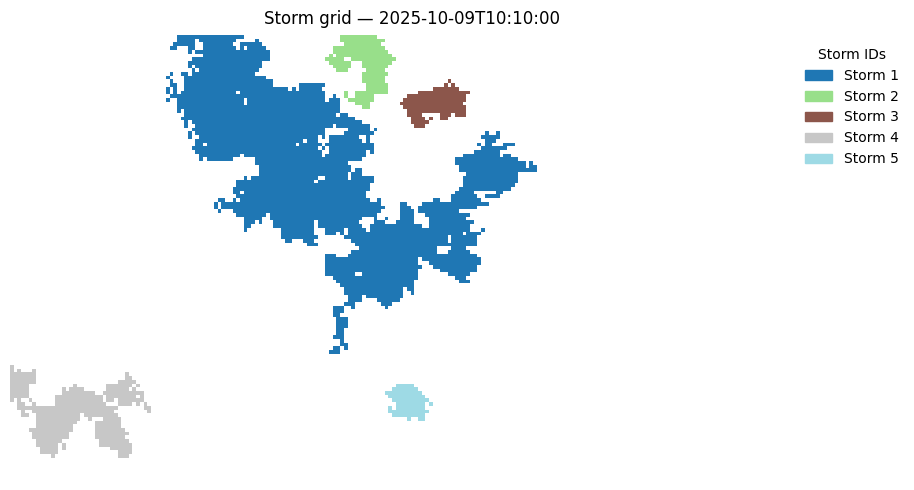

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# choose one grid
grid = possible_storm_grid_combined.loc[2, "grid"]
timestamp = possible_storm_grid_combined.loc[2, "timestamp"]

# non-zero storm IDs
labels = np.unique(grid)
labels = labels[labels != 0]

# build colors for storms (skip background)
base = plt.get_cmap("tab20", len(labels))
storm_colors = [base(i) for i in range(len(labels))]

# remap grid to 0..K-1 for coloring; keep background as NaN to make it transparent
remap = np.full_like(grid, fill_value=np.nan, dtype=float)
for i, lab in enumerate(labels):
    remap[grid == lab] = i  # 0..K-1

# colormap with NO color for background (alpha=0)
cmap = ListedColormap(storm_colors)

fig, ax = plt.subplots(figsize=(10, 5))

# make canvas transparent
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')         # transparent plotting area
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])

# draw storms only (background NaN won't be drawn)
im = ax.imshow(remap, cmap=cmap, origin='upper', interpolation='nearest')

# legend with actual grid IDs
patches = [mpatches.Patch(color=storm_colors[i], label=f"Storm {lab}") 
           for i, lab in enumerate(labels)]
ax.legend(handles=patches, title="Storm IDs", loc="upper right",
          bbox_to_anchor=(1.12, 1), frameon=False)

ax.set_title(f"Storm grid — {timestamp}", pad=8)
plt.tight_layout()
plt.show()

# if you want to save with real transparency:
# plt.savefig("storm_grid.png", dpi=200, transparent=True)